EDA

In [81]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [82]:
df = pd.read_csv("insurance.csv")

In [83]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [84]:
df.shape

(1338, 7)

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [86]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [87]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

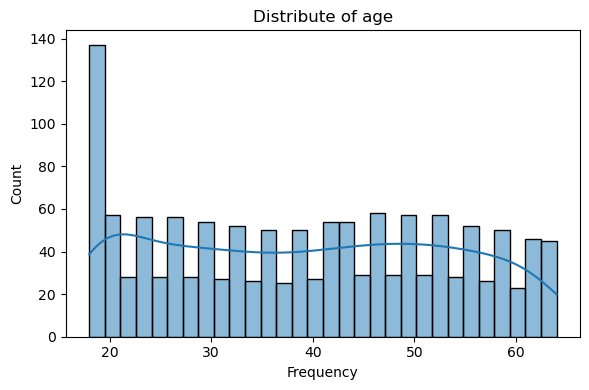

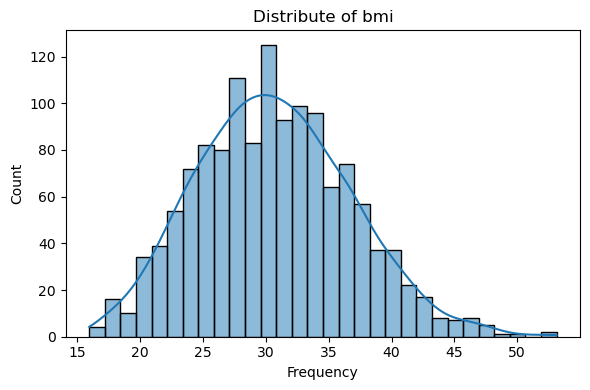

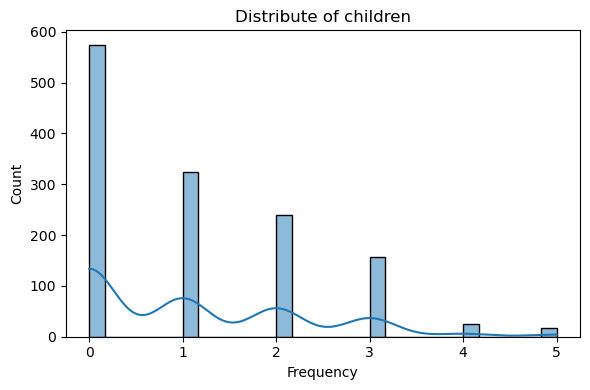

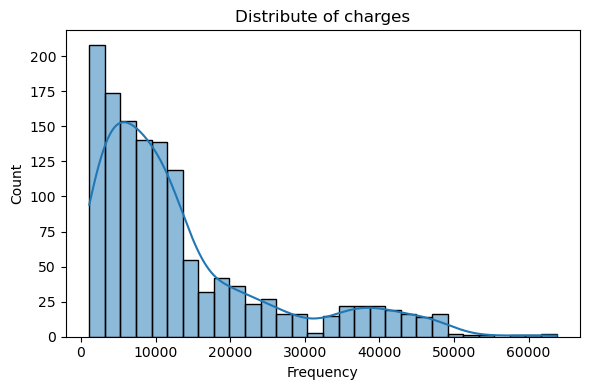

In [88]:
numerical_columns = ['age','bmi','children','charges']
for col in numerical_columns: 
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 30)
    plt.title(f'Distribute of {col}')
    plt.xlabel(col)
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

<Axes: xlabel='children', ylabel='count'>

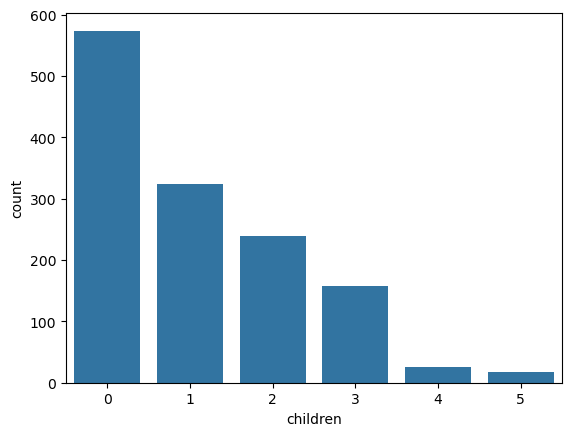

In [89]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

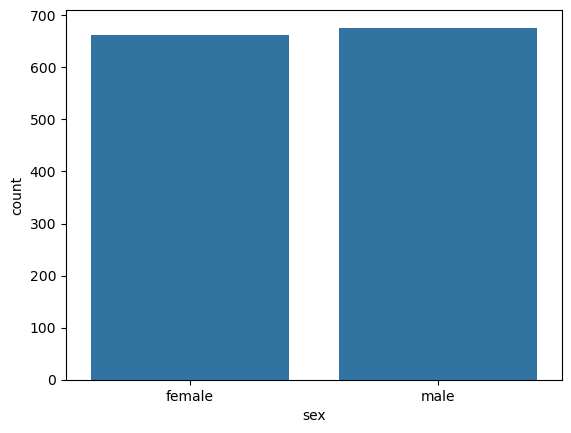

In [90]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

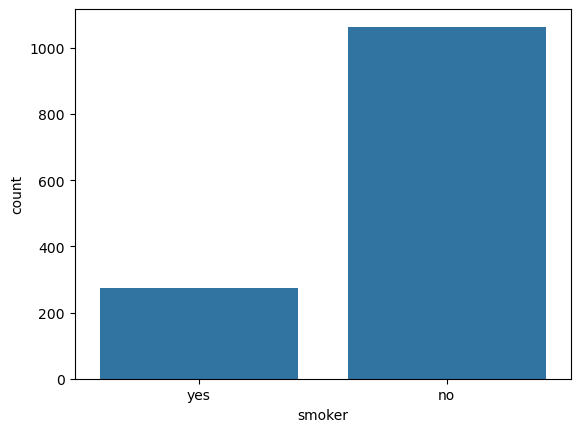

In [91]:
sns.countplot(x = df['smoker'])

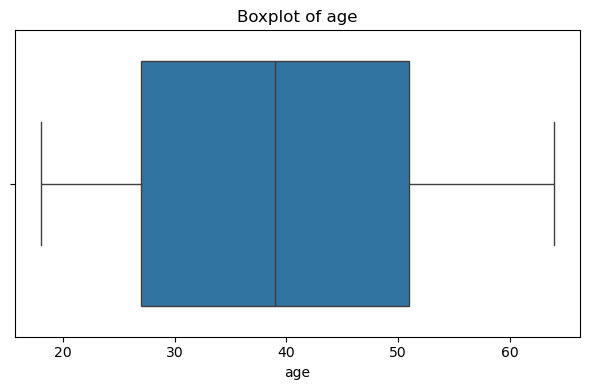

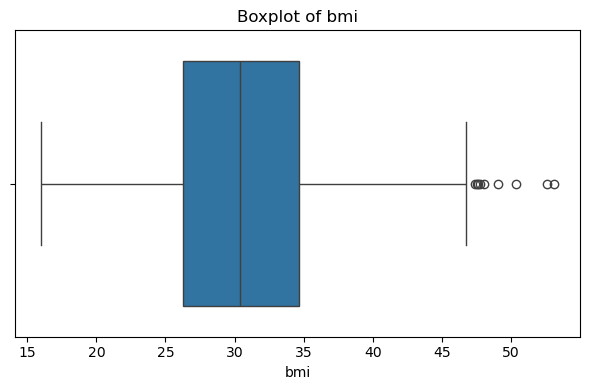

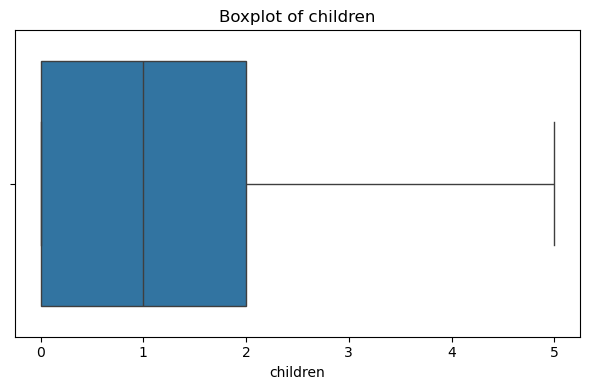

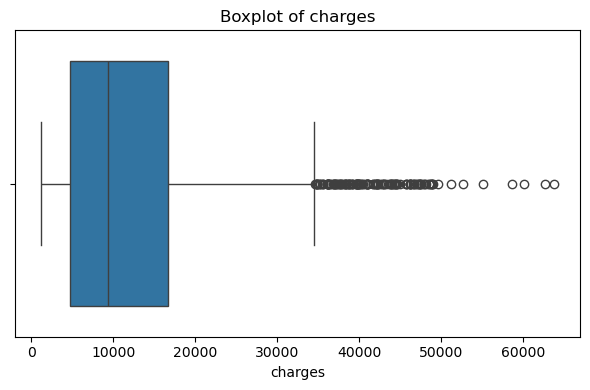

In [92]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

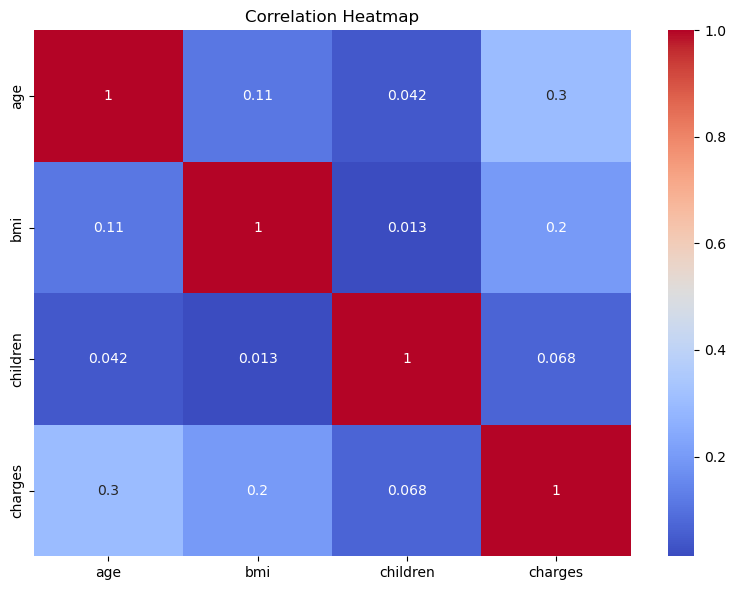

In [93]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

DATA CLEANING AND ROPROCESSING

In [94]:
df_cleaned = df.copy()

In [95]:
df_cleaned.drop_duplicates(inplace=True)

In [96]:
df_cleaned.shape

(1337, 7)

In [97]:
print("Missing Values:\n",df_cleaned.isnull().sum())

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [98]:
print("\n Data Types:\n",df_cleaned.dtypes)


 Data Types:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [99]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [100]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})

In [101]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [102]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})

In [103]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [104]:
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [105]:
print(df_cleaned.columns)


Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region',
       'charges'],
      dtype='str')


In [108]:
# 1. Load data
df_cleaned = df.copy()

# 2. Encode sex & smoker FIRST
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})

# 3. One-hot encode region
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

# 4. Rename columns
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [109]:
df_cleaned = df_cleaned.astype(int)

Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

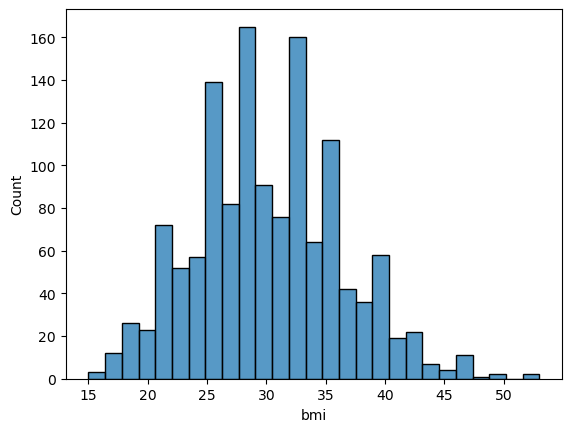

In [110]:
sns.histplot(df_cleaned['bmi'])

In [111]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']
)

In [112]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [113]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [114]:
df_cleaned = df_cleaned.astype(int)

In [115]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='str')

In [116]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])


In [117]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,1,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,1,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,1,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,1,0,0,0,1,0


In [123]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

# Calculate Pearson correlation
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,0.787251
0,age,0.299009
10,bmi_category_Obese,0.199533
1,bmi,0.196188
6,region_southeast,0.073981
2,children,0.067999
5,region_northwest,-0.039905
7,region_southwest,-0.043210
3,is_female,-0.057293
8,bmi_category_Normal,-0.103679


In [124]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [125]:
from scipy.stats import chi2_contingency
import pandas as pd

# Define significance level
alpha = 0.05

# Bin the target variable
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

# Run Chi-Square test
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert to DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
is_smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
is_female,9.532132,0.022992,Reject Null (Keep Feature)
bmi_category_Obese,8.510101,0.036566,Reject Null (Keep Feature)
region_southwest,5.530825,0.136807,Accept Null (Drop Feature)
bmi_category_Overweight,4.620089,0.201826,Accept Null (Drop Feature)
bmi_category_Normal,3.578987,0.310661,Accept Null (Drop Feature)
region_northwest,1.226112,0.746749,Accept Null (Drop Feature)


In [137]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'charges_bin'],
      dtype='str')

In [138]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese','region_northwest']]

In [139]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese,region_northwest
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1,0
2,-0.797954,0,0.462657,1.580926,0,4449,1,1,0
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0,1
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0,1
...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1,0
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1,0
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0,0


In [140]:
from sklearn.model_selection import train_test_split


In [141]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [143]:
from sklearn.linear_model import LinearRegression

In [144]:
model = LinearRegression()

In [145]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_pred = model.predict(X_test)

In [149]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.7745110003151044